# MLE debug — re-evaluate Chisq + MLE fits under the MLE objective

Flow: load behavior + both fit-result pickles, then for a chosen subject
feed BOTH its Chisq-fitted and MLE-fitted parameter sets through
`evaluate_neg_loglik` to get two per-trial MLE diagnostic dataframes:

- `mle_chisq_df` — chisq-fitted params evaluated under MLE
- `mle_mle_df`   — mle-fitted params evaluated under MLE

Then compare them trial-by-trial to find which trials disagree the
most. This is the debug flow for case 2 (Chisq visually wins, MLE
disagrees).

## Enable loading from relative packages

In [ ]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg

## Load all mice data

Identical to `model_interactive.ipynb`: this creates the `df_behavior`
global that every other cell consumes.

In [ ]:
# Behavior-dataframe prep now lives in model/mle_reeval.py (shared with
# model_compare.ipynb) — same loadDF → calcAvgRewardRate → _reduceDFSize →
# _extendTrials pipeline this cell used to inline.
from .model.mle_reeval import prepare_behavior_df

df_behavior = prepare_behavior_df()

## Load fit results (MLE + Chisq)

Creates the `fit_results_by_mode` global with the same shape as in
`model_interactive.ipynb`.

In [ ]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

RESULT_DIR = Path("../../data/RLModel")
FIT_MODES = ("mle", "chisq")


def _load_pickle(path):
    with path.open("rb") as f:
        return pickle.load(f)


def loadFitResults(result_dir=RESULT_DIR, all_subjects=None):
    fit_results_by_mode = {mode: {} for mode in FIT_MODES}
    for mode in FIT_MODES:
        for fit_path in sorted(result_dir.glob(f"{mode}_*.pkl")):
            print("Processing:", fit_path)
            loaded = _load_pickle(fit_path)
            fit_results_by_mode[mode][fit_path.name] = loaded
            if all_subjects is not None:
                missing = all_subjects - set(loaded.keys())
                if missing:
                    print("  Missing subjects:", missing)
    return fit_results_by_mode


fit_results_by_mode = loadFitResults(
    all_subjects=set(df_behavior.Name.unique()))

Processing: ..\..\data\RLModel\mle_Classic_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\mle_Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\mle_Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\mle_NoiseGain-RewardRate Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\mle_NoiseGain-RewardRate_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\mle_NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\chisq_Classic_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\chisq_Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\chisq_NoiseGain-RewardRate Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\chisq_NoiseGain-RewardRate_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Processing: ..\..\data\RLModel\chisq_NoiseGain-

## Helpers — parse filename + re-evaluate any fit under MLE

`fitted_params_to_mle_df` works for both `chisq_*.pkl` and `mle_*.pkl`
variants — the filename's prefix selects which `fit_results_by_mode`
bucket to read from. The optional `lapse_rate_override` lets the driver
force a specific λ value on either fit type (most useful for forcing the
chisq-fitted params to use the same λ as the mle-fitted params for a
fair comparison).

In [ ]:
# Filename parsing + MLE re-evaluation now live in model/mle_reeval.py
# (shared with model_compare.ipynb). `fitted_params_to_mle_df` keeps the same
# (mle_df, eval_result, model_config, params) contract this notebook relies on.
from .model.mle_reeval import parse_fit_filename, fitted_params_to_mle_df
from .model.mle_likelihood import LOGLIK_FLOOR
import numpy as np
import pandas as pd


def list_variants(fit_results_by_mode, fit_mode, subject_name=None):
    """Variant filenames for the given fit_mode, optionally filtered to
    those that contain `subject_name`."""
    out = []
    for filename, fit_dict in fit_results_by_mode.get(fit_mode, {}).items():
        if subject_name is None or subject_name in fit_dict:
            out.append(filename)
    return out


def list_subjects(fit_results_by_mode, variant_filename):
    """Subjects that have a fit in `variant_filename`."""
    fit_mode = parse_fit_filename(variant_filename).fit_mode
    return sorted(fit_results_by_mode[fit_mode][variant_filename].keys())


def _evaluate_one(subject_name, variant_filename, label,
                  df_behavior, fit_results_by_mode, mle_terminal_c,
                  lapse_rate_override):
    mle_df, eval_res, config, params = fitted_params_to_mle_df(
        subject_name, variant_filename, df_behavior, fit_results_by_mode,
        mle_terminal_c=mle_terminal_c,
        lapse_rate_override=lapse_rate_override)
    effective_lapse = float(params.get("LAPSE_RATE", 0.0))
    lapse_source = ("overridden" if lapse_rate_override is not None
                    else "from fit")
    print(f"[{label}] variant         : {variant_filename}")
    print(f"[{label}] LAPSE_RATE used : {effective_lapse:.6f} "
          f"({lapse_source})")
    print(f"[{label}] neg_loglik (MLE): {eval_res.neg_loglik:.3f}")
    print(f"[{label}] n_trials_loss   : {eval_res.n_trials_loss} / "
          f"{eval_res.n_trials_total}")
    print()
    return mle_df, eval_res, config, params


# ----- Single-df inspection ---------------------------------------------

def summarize_trial_losses(mle_df, top_n=20):
    """One-shot per-trial diagnostic: floor count, by-class loglik, worst trials."""
    valid = mle_df[mle_df["mle_valid_for_loss"].astype(bool)].copy()
    no_choice = valid[valid["ChoiceLeft"].isna()]
    choice = valid[valid["ChoiceLeft"].notna()]
    floor_log = float(np.log(LOGLIK_FLOOR))
    n_floor = int((valid["mle_loglik"] <= floor_log * 0.99).sum())

    print(f"valid trials       : {len(valid):>6d}")
    print(f"  choice trials    : {len(choice):>6d}  "
          f"mean_loglik = {choice['mle_loglik'].mean():>+9.3f}")
    if len(no_choice):
        print(f"  no-choice trials : {len(no_choice):>6d}  "
              f"mean_loglik = {no_choice['mle_loglik'].mean():>+9.3f}")
    else:
        print(f"  no-choice trials : 0")
    pct = 100.0 * n_floor / max(len(valid), 1)
    print(f"trials at floor    : {n_floor:>6d}  ({pct:.1f}%)")
    print(f"total neg_loglik   : {-valid['mle_loglik'].sum():>10.3f}")

    cols = [c for c in [
        "TrialNumber", "DV", "ChoiceLeft", "ChoiceCorrect",
        "calcStimulusTime", "mle_z", "mle_mu", "mle_sigma",
        "mle_decision_time_observed", "mle_choice_prob_or_density",
        "mle_survival_at_tmax", "mle_loglik",
    ] if c in mle_df.columns]
    return valid.nsmallest(top_n, "mle_loglik")[cols]


def plot_trial_loss_histogram(mle_df, bins=60, title_suffix=""):
    """Per-trial loglik histogram split by choice / no-choice."""
    import matplotlib.pyplot as plt
    valid = mle_df[mle_df["mle_valid_for_loss"].astype(bool)]
    choice = valid[valid["ChoiceLeft"].notna()]["mle_loglik"].to_numpy()
    no_choice = valid[valid["ChoiceLeft"].isna()]["mle_loglik"].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(choice, bins=bins, alpha=0.7, label=f"choice (n={len(choice)})")
    if len(no_choice):
        ax.hist(no_choice, bins=bins, alpha=0.7,
                label=f"no-choice (n={len(no_choice)})")
    ax.axvline(float(np.log(LOGLIK_FLOOR)), color="r", ls="--",
               label="log(LOGLIK_FLOOR)")
    ax.set_xlabel("per-trial mle_loglik")
    ax.set_ylabel("count")
    ax.set_title(f"Per-trial loglik distribution{title_suffix}")
    ax.legend()
    fig.tight_layout()
    return fig


def loss_by_rt_bin(mle_df, n_bins=10):
    v = mle_df[mle_df["mle_valid_for_loss"].astype(bool)
               & mle_df["ChoiceLeft"].notna()].copy()
    v["rt_bin"] = pd.qcut(v["calcStimulusTime"], n_bins, duplicates="drop")
    return v.groupby("rt_bin", observed=True)["mle_loglik"].agg(
        ["count", "mean", "min"])


def loss_by_dv(mle_df, n_bins=8):
    v = mle_df[mle_df["mle_valid_for_loss"].astype(bool)
               & mle_df["ChoiceLeft"].notna()].copy()
    v["dv_bin"] = pd.qcut(v["DV"], n_bins, duplicates="drop")
    return v.groupby("dv_bin", observed=True)["mle_loglik"].agg(
        ["count", "mean", "min"])


# ----- Two-df comparison ------------------------------------------------

def compare_loglik_per_trial(mle_chisq_df, mle_mle_df):
    """Side-by-side per-trial loglik DataFrame.

    Both DFs come from `fitted_params_to_mle_df` for the same subject and
    therefore share the same row index — index-based subtraction is exact.
    Returns a frame with `mle_chisq_loglik`, `mle_mle_loglik`,
    `delta_loglik = mle_mle_loglik - mle_chisq_loglik`. Positive `delta`
    means the MLE-fitted parameters fit that trial better.
    """
    common = [c for c in (
        "TrialNumber", "DV", "ChoiceLeft", "ChoiceCorrect",
        "calcStimulusTime") if c in mle_chisq_df.columns]
    out = mle_chisq_df[common].copy()
    out["mle_chisq_loglik"] = mle_chisq_df["mle_loglik"]
    out["mle_mle_loglik"] = mle_mle_df["mle_loglik"]
    out["delta_loglik"] = (
        mle_mle_df["mle_loglik"] - mle_chisq_df["mle_loglik"])
    out["mle_chisq_valid"] = mle_chisq_df["mle_valid_for_loss"]
    out["mle_mle_valid"] = mle_mle_df["mle_valid_for_loss"]
    out["mle_chisq_z"] = mle_chisq_df["mle_z"]
    out["mle_mle_z"] = mle_mle_df["mle_z"]
    out["mle_chisq_mu"] = mle_chisq_df["mle_mu"]
    out["mle_mle_mu"] = mle_mle_df["mle_mu"]
    out["mle_chisq_sigma"] = mle_chisq_df["mle_sigma"]
    out["mle_mle_sigma"] = mle_mle_df["mle_sigma"]
    return out


def summarize_comparison(mle_chisq_df, mle_mle_df, top_n=10):
    """Print head-to-head comparison + worst trials in each direction.
    Returns the full comparison DataFrame for further filtering."""
    cmp = compare_loglik_per_trial(mle_chisq_df, mle_mle_df)
    both_valid = cmp[cmp["mle_chisq_valid"] & cmp["mle_mle_valid"]].copy()
    delta = both_valid["delta_loglik"]
    print(f"valid in both             : {len(both_valid)}")
    print(f"sum Δloglik               : {delta.sum():+10.3f}")
    print(f"  (positive ⇒ MLE-fitted params win in aggregate)")
    print(f"mean Δloglik per trial    : {delta.mean():+10.4f}")
    print(f"median Δloglik per trial  : {delta.median():+10.4f}")
    print(f"trials MLE-fitted better  : {int((delta > 0).sum())}")
    print(f"trials Chisq-fitted better: {int((delta < 0).sum())}")
    print(f"trials tied (Δ=0)         : {int((delta == 0).sum())}")
    print()
    print(f"=== Top {top_n} trials where MLE-fitted wins by the most ===")
    display(both_valid.nlargest(top_n, "delta_loglik"))
    print(f"\n=== Top {top_n} trials where Chisq-fitted wins by the most ===")
    display(both_valid.nsmallest(top_n, "delta_loglik"))
    return cmp


def plot_loglik_scatter(mle_chisq_df, mle_mle_df):
    """Scatter of per-trial mle_loglik: chisq-fitted (x) vs mle-fitted (y).
    Points above y=x: MLE-fitted parameters fit that trial better."""
    import matplotlib.pyplot as plt
    cmp = compare_loglik_per_trial(mle_chisq_df, mle_mle_df)
    both_valid = cmp[cmp["mle_chisq_valid"] & cmp["mle_mle_valid"]]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(both_valid["mle_chisq_loglik"],
               both_valid["mle_mle_loglik"], s=8, alpha=0.4)
    lo = float(min(both_valid["mle_chisq_loglik"].min(),
                   both_valid["mle_mle_loglik"].min()))
    hi = float(max(both_valid["mle_chisq_loglik"].max(),
                   both_valid["mle_mle_loglik"].max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    ax.set_xlabel("per-trial mle_loglik (chisq-fitted params)")
    ax.set_ylabel("per-trial mle_loglik (mle-fitted params)")
    ax.set_title("Per-trial loglik: chisq vs mle parameters\n"
                 "(above diagonal ⇒ mle-fitted wins this trial)")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_delta_histogram(mle_chisq_df, mle_mle_df, bins=60):
    """Histogram of Δloglik per trial. Positive → MLE-fitted wins."""
    import matplotlib.pyplot as plt
    cmp = compare_loglik_per_trial(mle_chisq_df, mle_mle_df)
    both_valid = cmp[cmp["mle_chisq_valid"] & cmp["mle_mle_valid"]]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(both_valid["delta_loglik"], bins=bins)
    ax.axvline(0.0, color="k", ls="--")
    ax.set_xlabel("Δ mle_loglik (mle-fitted − chisq-fitted)")
    ax.set_ylabel("count")
    ax.set_title("Per-trial loglik difference")
    fig.tight_layout()
    return fig

## Driver — specify subject + variant pair, produce both DFs

Set `SUBJECT_NAME`, then pick the chisq variant and the mle variant
(usually the same drift/bias/noise family in both, so they're directly
comparable). The cell assigns these globals for downstream cells:

- `mle_chisq_df`, `mle_chisq_eval`, `mle_chisq_config`, `mle_chisq_params`
- `mle_mle_df`,   `mle_mle_eval`,   `mle_mle_config`,   `mle_mle_params`

`MLE_LAPSE_RATE` controls the λ used in the re-evaluation:

- `None` (default): use each fit's baked-in value. Chisq fits don't fit
  `LAPSE_RATE`, so chisq → λ=0. MLE fits return the DE-found λ.
- `0.0`: disable lapse for both re-evaluations.
- e.g. `0.02`: apply the same fixed λ to both for an apples-to-apples
  comparison (gives chisq params the same outlier-protection the MLE
  fit had — clarifies whether MLE wins on signal or just on robustness).

In [ ]:
#SUBJECT_NAME = "FILL_ME_IN"
#SUBJECT_NAME = "Avgat3"
SUBJECT_NAME = "Rbp4_M2_1"
# Pair these so they share the same drift/bias/noise family for a
# like-for-like comparison.
#VARIANT_BASE = "Classic_biasNone__Normal(0, 1)_3s_dt0.005"
# VARIANT_BASE = "NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005"
VARIANT_BASE = "Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005"
CHISQ_VARIANT_FILENAME = f"chisq_{VARIANT_BASE}.pkl"
MLE_VARIANT_FILENAME   = f"mle_{VARIANT_BASE}.pkl"
# 0.99 mirrors the legacy survival-mass treatment of no-choice trials
# (closer to what Chisq implicitly does). Set 0.0 to floor no-choice
# likelihoods to LOGLIK_FLOOR.
# MLE_TERMINAL_C = 0.99
MLE_TERMINAL_C = 0
# Lapse-rate override (λ) for both re-evaluations:
#   - None: use the value baked into each fit's params dict (chisq → 0,
#           mle → DE-found λ).
#   - 0.0:  disable lapse on both sides.
#   - 0.02: apply the same λ to both for an apples-to-apples comparison.
# MLE_LAPSE_RATE = None
MLE_LAPSE_RATE = None


if SUBJECT_NAME == "FILL_ME_IN":
    print("Set SUBJECT_NAME (and optionally the variant filenames) above, "
          "then re-run this cell.\n")
    print("Chisq variants:")
    for v in list_variants(fit_results_by_mode, "chisq"):
        print("  -", v)
    print("MLE variants:")
    for v in list_variants(fit_results_by_mode, "mle"):
        print("  -", v)
else:
    print(f"Subject     : {SUBJECT_NAME}")
    print(f"terminal_c  : {MLE_TERMINAL_C}")
    lapse_display = (
        f"{MLE_LAPSE_RATE}" if MLE_LAPSE_RATE is not None
        else "<from each fit>")
    print(f"lapse_rate  : {lapse_display}\n")
    (mle_chisq_df, mle_chisq_eval, mle_chisq_config,
     mle_chisq_params) = _evaluate_one(
        SUBJECT_NAME, CHISQ_VARIANT_FILENAME, "chisq-fitted",
        df_behavior, fit_results_by_mode, MLE_TERMINAL_C, MLE_LAPSE_RATE)
    (mle_mle_df, mle_mle_eval, mle_mle_config,
     mle_mle_params) = _evaluate_one(
        SUBJECT_NAME, MLE_VARIANT_FILENAME, "mle-fitted",
        df_behavior, fit_results_by_mode, MLE_TERMINAL_C, MLE_LAPSE_RATE)
    dn = mle_mle_eval.neg_loglik - mle_chisq_eval.neg_loglik
    print(f"Δ neg_loglik (mle-fitted - chisq-fitted): {dn:+.3f}")
    print("  (negative ⇒ MLE-fitted parameters fit better under MLE)")


Subject     : Rbp4_M2_1
terminal_c  : 0
lapse_rate  : <from each fit>

Resolving MLE array backend (requested=numpy, device_id=None, cupy_fallback=error)...
[chisq-fitted] variant         : chisq_Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
[chisq-fitted] LAPSE_RATE used : 0.000000 (from fit)
[chisq-fitted] neg_loglik (MLE): 125885.580
[chisq-fitted] n_trials_loss   : 3447 / 7182

[mle-fitted] variant         : mle_Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
[mle-fitted] LAPSE_RATE used : 0.125667 (from fit)
[mle-fitted] neg_loglik (MLE): 4168.857
[mle-fitted] n_trials_loss   : 3447 / 7182

Δ neg_loglik (mle-fitted - chisq-fitted): -121716.723
  (negative ⇒ MLE-fitted parameters fit better under MLE)


## Inspection helpers

All helpers are functions that take a dataframe (or two) as input — so
the same code works on either `mle_chisq_df` or `mle_mle_df`, and the
comparison helpers operate on both at once.

## Inspect each DF individually

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from .model.mle_reeval import plot_rt_hist_colored_by_loss, plot_loss_distribution

def debug(mle_df):
    mle_df = mle_df[mle_df.valid == True]
    print(f"Sum of MLE log-likelihood: {mle_df.mle_loglik.sum():,.3f}")
    CUT_OFF = -40
    outlier_mask = mle_df.mle_loglik < CUT_OFF
    print(f"Number of outlier trials (loglik <= {CUT_OFF}): {(outlier_mask).sum():,}/{len(mle_df):,}")
    print(f"Sum of MLE log-likelihood without outliers: {mle_df.loc[~outlier_mask].mle_loglik.sum():,.3f}")
    # RT hist coloured by loss + per-trial -loglik distribution now come from
    # model/mle_reeval.py (shared with model_compare.ipynb's grid rows).
    fig, ax = plt.subplots()
    plot_rt_hist_colored_by_loss(ax, mle_df, cut_off=CUT_OFF, t_dur=3.0)
    plt.show()
    fig, ax = plt.subplots()
    plot_loss_distribution(ax, mle_df, ylim=850)
    plt.show()
    # display(outliers_df.head(50))
    display(mle_df[["SessId", #"valid",
                    "TrialNumber", "DV", "ChoiceLeft", "ChoiceCorrect", "EarlyWithdrawal",
                    "PrevChoiceCorrect", "PrevOutcomeCount", "RewardRate5",
                     "calcStimulusTime", "mle_z", "mle_mu", "mle_sigma",
                    "mle_decision_time_observed","mle_choice_prob_or_density","mle_loglik","mle_valid_for_loss"]]
                    .sort_values("mle_loglik").head(20))
    #import matplotlib.pyplot as plt
    #_ = plt.hist(mle_df.mle_loglik, bins=60)
    total_len = len(mle_df)
    less_than_li = [-np.inf,
                    -700, -600, -500, -400, -300, -200, -100,
                    -90, -80, -70, -60, -50, -40, -30, -20, -10,
                    -9, -8, -7, -6, -5, -4, -3, -2, -1, 0,
                    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                    np.inf]
    last_num_digits = len(str(less_than_li[0]))
    last_limit = -np.inf
    prcnt_so_far = 0
    for threshold in less_than_li:
        num_digits = len(str(threshold))
        if last_num_digits != num_digits:
            print()  # Add a blank line when we cross an order of magnitude
            last_num_digits = num_digits
        count = (mle_df.mle_loglik <= threshold).sum()
        if last_limit == count:
            continue
        count_this_bin = count - (last_limit if np.isfinite(last_limit) else 0)
        last_limit = count
        prcnt = 100 * count_this_bin / total_len
        prcnt_so_far += prcnt
        print(f"Trials with loglik <= {threshold:>6}: {count_this_bin:,} / {total_len:,} "
              f"({prcnt:.2f}%)")
    print(f"Total percentage accounted for: {prcnt_so_far:.2f}%")

# print("Chisq-fitted parameters:")
# debug(mle_chisq_df)

print("\nMLE-fitted parameters:")
debug(mle_mle_df)

=== CHISQ-FITTED params, evaluated under MLE ===

Top-20 worst trials:
valid trials       :   3447
  choice trials    :   3447  mean_loglik =   -36.520
  no-choice trials : 0
trials at floor    :    169  (4.9%)
total neg_loglik   : 125885.580


,TrialNumber,DV,ChoiceLeft,ChoiceCorrect,calcStimulusTime,mle_z,mle_mu,mle_sigma,mle_decision_time_observed,mle_choice_prob_or_density,mle_survival_at_tmax,mle_loglik
33862,146,-0.5,1.0,0.0,0.3216,0.029020,-0.668055,0.988003,-0.042527,1.000000e-300,0.024012,-690.775528
33870,154,1.0,1.0,1.0,0.3572,0.028936,1.336110,0.988003,-0.006927,1.000000e-300,0.003357,-690.775528
33871,155,0.1,1.0,1.0,0.3573,0.033033,0.133611,0.988003,-0.006827,1.000000e-300,0.043078,-690.775528
33872,156,-1.0,1.0,0.0,0.3302,0.033117,-1.336110,0.988003,-0.033927,1.000000e-300,0.003643,-690.775528
33876,160,-1.0,1.0,0.0,0.3287,0.806818,-1.336110,0.988003,-0.035427,1.000000e-300,0.003600,-690.775528
33882,166,1.0,0.0,0.0,0.3502,0.028935,1.336110,0.988003,-0.013927,1.000000e-300,0.003357,-690.775528
33904,188,-1.0,0.0,1.0,0.3483,0.033117,-1.336110,0.988003,-0.015827,1.000000e-300,0.003643,-690.775528
33921,205,-0.5,0.0,1.0,0.3077,0.956334,-0.668055,0.988003,-0.056427,1.000000e-300,0.006247,-690.775528
33974,258,-1.0,1.0,0.0,0.3482,0.952237,-1.336110,0.988003,-0.015927,1.000000e-300,0.001771,-690.775528
33975,259,0.5,1.0,1.0,0.3478,0.174357,0.668055,0.988003,-0.016327,1.000000e-300,0.020296,-690.775528



Mean loglik by RT bin (choice trials):


,count,mean,min
rt_bin,,,
"(0.302, 0.414]",345,-344.406723,-690.775528
"(0.414, 0.471]",346,-5.250806,-29.297976
"(0.471, 0.533]",344,-2.519698,-15.977348
"(0.533, 0.621]",344,-1.817819,-10.791953
"(0.621, 0.758]",345,-1.113363,-8.275019
"(0.758, 0.956]",344,-1.134131,-6.958339
"(0.956, 1.201]",345,-1.300070,-5.446049
"(1.201, 1.533]",345,-1.664937,-5.576931
"(1.533, 2.042]",344,-2.384127,-5.503542



Mean loglik by DV bin (choice trials):


...

,TrialNumber,DV,ChoiceLeft,ChoiceCorrect,calcStimulusTime,mle_z,mle_mu,mle_sigma,mle_decision_time_observed,mle_choice_prob_or_density,mle_survival_at_tmax,mle_loglik
35046,133,1.0,0.0,0.0,2.9860,0.028616,1.271656,1.235413,2.744791,0.021779,0.001612,-3.826792
33921,205,-0.5,0.0,1.0,0.3077,0.441068,-0.635828,1.235413,0.066491,0.021952,0.004848,-3.818901
36047,336,-0.9,1.0,0.0,2.8642,0.055938,-1.144490,1.235413,2.622991,0.022591,0.002282,-3.790198
34177,62,1.0,0.0,0.0,2.5388,-0.179141,1.271656,1.235413,2.297591,0.023530,0.001844,-3.749485
34597,83,-1.0,0.0,1.0,2.8282,-0.440466,-1.271656,1.235413,2.586991,0.024681,0.000891,-3.701711
34689,175,-0.5,1.0,0.0,2.9346,0.023046,-0.635828,1.235413,2.693391,0.025296,0.005200,-3.677097
40665,166,0.5,0.0,0.0,2.9305,-0.312953,0.635828,1.235413,2.689291,0.025362,0.005230,-3.674492
36154,44,0.9,1.0,1.0,2.9586,0.189623,1.144490,1.235413,2.717391,0.026144,0.001837,-3.644148
35744,33,-1.0,0.0,1.0,2.9796,0.115008,-1.271656,1.235413,2.738391,0.026304,0.001788,-3.638032
34722,208,-1.0,0.0,1.0,2.9399,0.020948,-1.271656,1.235413,2.698691,0.026499,0.001694,-3.630649



Mean loglik by RT bin (choice trials):


,count,mean,min
rt_bin,,,
"(0.302, 0.414]",345,-0.806417,-3.818901
"(0.414, 0.471]",346,-0.473852,-3.183380
"(0.471, 0.533]",344,-0.428273,-2.051810
"(0.533, 0.621]",344,-0.487897,-2.239413
"(0.621, 0.758]",345,-0.568235,-2.677651
"(0.758, 0.956]",344,-0.836591,-2.738261
"(0.956, 1.201]",345,-1.205865,-2.449463
"(1.201, 1.533]",345,-1.719577,-3.180287
"(1.533, 2.042]",344,-2.373370,-3.580352



Mean loglik by DV bin (choice trials):


,count,mean,min
dv_bin,,,
"(-1.001, -0.5]",1092,-1.144900,-3.818901
"(-0.5, -0.2]",286,-1.383662,-3.523936
"(-0.2, 0.1]",566,-1.298289,-3.534453
"(0.1, 0.2]",262,-1.492269,-3.586744
"(0.2, 0.5]",398,-1.290622,-3.674492
"(0.5, 1.0]",843,-1.047954,-3.826792


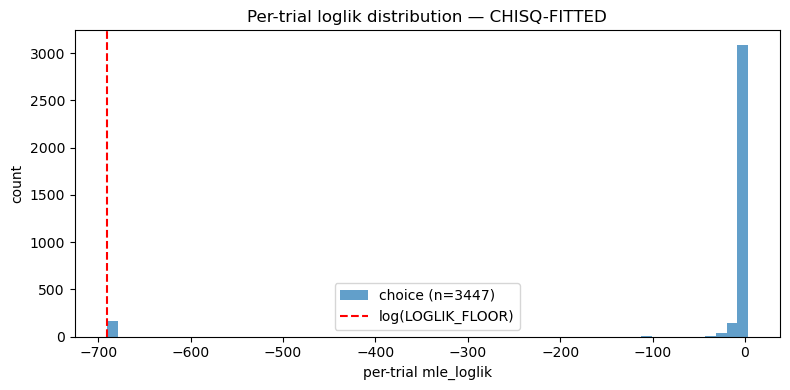

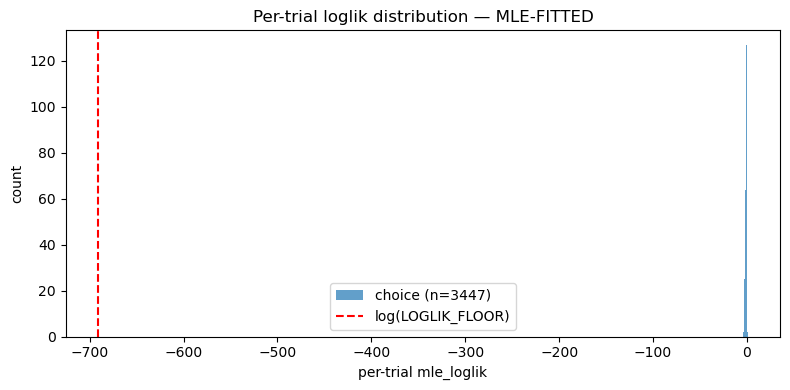

In [ ]:
def inspect_single(mle_df, label):
    print("=" * 60)
    print(f"=== {label} params, evaluated under MLE ===")
    print("=" * 60)
    print("\nTop-20 worst trials:")
    display(summarize_trial_losses(mle_df))
    print("\nMean loglik by RT bin (choice trials):")
    display(loss_by_rt_bin(mle_df))
    print("\nMean loglik by DV bin (choice trials):")
    display(loss_by_dv(mle_df))
    plot_trial_loss_histogram(mle_df, title_suffix=f" — {label}")


if "mle_chisq_df" not in globals() or "mle_mle_df" not in globals():
    print("No `mle_chisq_df` / `mle_mle_df` yet — run the driver cell above.")
else:
    inspect_single(mle_chisq_df, "CHISQ-FITTED")
    print("\n")
    inspect_single(mle_mle_df, "MLE-FITTED")

## Compare per-trial losses: chisq-fitted vs mle-fitted

Produces `cmp_df` (the merged comparison frame) as a global so you can
filter / sort / plot it further. Positive `delta_loglik` ⇒ MLE-fitted
parameters fit that trial better; negative ⇒ Chisq-fitted parameters
fit better.

valid in both             : 3447
sum Δloglik               : +121716.723
  (positive ⇒ MLE-fitted params win in aggregate)
mean Δloglik per trial    :   +35.3109
median Δloglik per trial  :    +0.3503
trials MLE-fitted better  : 2057
trials Chisq-fitted better: 1390
trials tied (Δ=0)         : 0

=== Top 10 trials where MLE-fitted wins by the most ===


,TrialNumber,DV,ChoiceLeft,ChoiceCorrect,calcStimulusTime,mle_chisq_loglik,mle_mle_loglik,delta_loglik,mle_chisq_valid,mle_mle_valid,mle_chisq_z,mle_mle_z,mle_chisq_mu,mle_mle_mu,mle_chisq_sigma,mle_mle_sigma
36417,307,0.9,1.0,1.0,0.3327,-690.775528,0.596722,691.372250,True,True,0.956250,0.318585,1.202499,1.144490,0.988003,1.235413
38574,70,0.6,1.0,1.0,0.3539,-690.775528,0.429504,691.205032,True,True,0.956250,0.286110,0.801666,0.762994,0.988003,1.235413
38202,97,1.0,1.0,1.0,0.3612,-690.775528,0.352199,691.127727,True,True,0.810914,0.176763,1.336110,1.271656,0.988003,1.235413
34583,69,1.0,1.0,1.0,0.3328,-690.775528,0.234565,691.010093,True,True,0.178452,0.182539,1.336110,1.271656,0.988003,1.235413
39794,93,0.5,1.0,1.0,0.3595,-690.775528,0.162971,690.938498,True,True,0.815009,0.201937,0.668055,0.635828,0.988003,1.235413
35118,205,-0.1,1.0,0.0,0.3608,-690.775528,0.130885,690.906413,True,True,0.956334,0.326197,-0.133611,-0.127166,0.988003,1.235413
34240,125,-0.5,0.0,1.0,0.3465,-690.775528,0.049309,690.824837,True,True,-0.886168,-0.181475,-0.668055,-0.635828,0.988003,1.235413
36306,196,1.0,1.0,1.0,0.3585,-690.775528,0.036676,690.812204,True,True,0.033035,0.062366,1.336110,1.271656,0.988003,1.235413
36223,113,1.0,1.0,1.0,0.3972,-690.775528,0.003569,690.779097,True,True,-0.740751,-0.032276,1.336110,1.271656,0.988003,1.235413
36754,245,1.0,1.0,1.0,0.3525,-690.775528,-0.011397,690.764131,True,True,0.033033,0.062048,1.336110,1.271656,0.988003,1.235413



=== Top 10 trials where Chisq-fitted wins by the most ===


,TrialNumber,DV,ChoiceLeft,ChoiceCorrect,calcStimulusTime,mle_chisq_loglik,mle_mle_loglik,delta_loglik,mle_chisq_valid,mle_mle_valid,mle_chisq_z,mle_mle_z,mle_chisq_mu,mle_mle_mu,mle_chisq_sigma,mle_mle_sigma
39126,223,-1.0,1.0,0.0,0.3816,1.799236,-1.065819,-2.865055,True,True,0.806817,0.147429,-1.336110,-1.271656,0.988003,1.235413
34174,59,0.1,0.0,0.0,0.3832,2.518017,-0.291981,-2.809998,True,True,-0.890183,-0.179141,0.133611,0.127166,0.988003,1.235413
36326,216,-1.0,1.0,0.0,0.3925,1.657489,-1.052920,-2.710410,True,True,0.806818,0.150716,-1.336110,-1.271656,0.988003,1.235413
34246,131,-1.0,0.0,1.0,0.3721,3.145077,0.491665,-2.653412,True,True,-0.890267,-0.215474,-1.336110,-1.271656,0.988003,1.235413
36022,311,-0.3,0.0,1.0,0.3819,2.599659,-0.012604,-2.612263,True,True,-0.890183,-0.168783,-0.400833,-0.381497,0.988003,1.235413
38658,154,-0.6,1.0,0.0,0.3903,1.800311,-0.663994,-2.464305,True,True,0.810832,0.170213,-0.801666,-0.762994,0.988003,1.235413
40567,68,-0.5,1.0,0.0,0.3769,1.905161,-0.537086,-2.442247,True,True,0.814927,0.196734,-0.668055,-0.635828,0.988003,1.235413
34576,62,-0.1,1.0,0.0,0.3795,2.441093,0.061675,-2.379418,True,True,0.956334,0.303136,-0.133611,-0.127166,0.988003,1.235413
40612,113,0.1,0.0,0.0,0.3971,1.617114,-0.736489,-2.353602,True,True,-0.740662,-0.012258,0.133611,0.127166,0.988003,1.235413
35936,225,0.3,0.0,0.0,0.3800,2.475154,0.136393,-2.338761,True,True,-0.886170,-0.409336,0.400833,0.381497,0.988003,1.235413


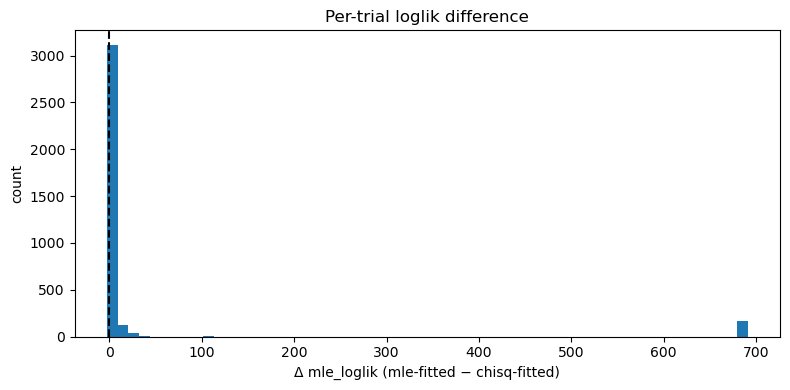

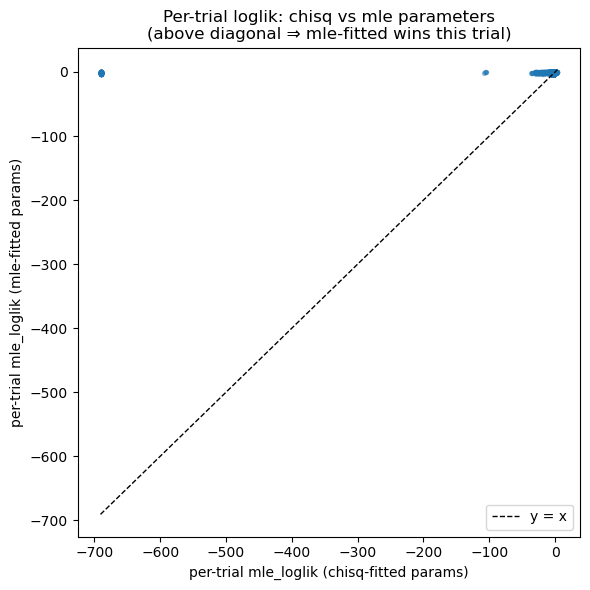

In [ ]:
if "mle_chisq_df" not in globals() or "mle_mle_df" not in globals():
    print("No `mle_chisq_df` / `mle_mle_df` yet — run the driver cell above.")
else:
    cmp_df = summarize_comparison(mle_chisq_df, mle_mle_df)
    plot_delta_histogram(mle_chisq_df, mle_mle_df)
    plot_loglik_scatter(mle_chisq_df, mle_mle_df)